**N3b_graphs**: Reproduces plots from Brandon's article, with the simulated signal vs. observations.

### 1. Initialization

Imports and general parameters (from *parameters.py*).

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import sys
import satellite_RFI.src.simulation as sim
sys.path.insert(0, './initialization/')
from imports import *
import parameters as pm


In [3]:
## ----- FITTING PARAMETERS ----- ##
# folder of final results
folder = "results/v6_results/"

# simulation information
path_beam = "{}satbeams_{}_{}_{}-{}.pkl".format(pm.folder, pm.block, pm.beam_model, *pm.freq_range)
path_catalog = f"{pm.folder}catalog_{pm.block}.csv"  # <-- using old catalog in ID format
path_nearby = f"{pm.folder}nearby_{pm.block}.pkl"
label_sats = "NORAD ID"


In [4]:
pm.show_parameters(plotting=True)
print("")
print(f"Showing results from folder: {folder}")


Block: 1551055211
Frequency range: 1100 - 1350 MHz

Showing results from folder: results/v6_results/


### 2. Set-up of global variables and functions

We start by defining some global variables (like the simulation and some functions) which will be the same for all of the masks.start by defining some global variables (like the simulation and some functions) which will be the same for all of the masks.

In [5]:
# we can use the same object throughout everything, only the mask changes
sat = sim.SatelliteSimulation(
    survey_info=[pm.nd_s0, pm.frequency],
    path_catalog=path_catalog,
    path_beam=path_beam,
    freq_range=pm.freq_range,
    freq_slice=pm.freq_slice,
    time_slice=(None,None),
    label_sats=label_sats,
    verbose=True,
)

# getting observations
sat.use_observations(path_observations=pm.path_observations, verbose=True)

# these values are the same always
frequency = sat.frequency[sat.ifreq[0]:sat.ifreq[1]]
time = sat.time[sat.itime[0]:sat.itime[1]]
N = len(sat.catalog)


Getting catalog...
 - Number of signals in satellite catalog: 248 (initial), 131 (final).
Getting beam response...
 - Number of satellites present: 60
 - Size of sat_beam: 1.181 GB
Getting temperature factors for each signal...
 - Length of Tb_factors: 131
 - Size of Tb_factors: 0.001 GB
Getting observational data...
 - Size of observational data: 0.020 GB
 - Shape of observational data: (1199, 2204)


In [6]:
## ----- PLOTTING FUNCTIONS (except for no mask) ----- ##

def get_results(mask, pars):
    ''' Retrieve alphas from the file. '''

    # storing values
    alphas = {p: [] for p in pars}
    sims = {p: [] for p in pars}
    CFs = {p: [] for p in pars}
    obs_BGsubs = {}

    for p in pars:
        # creating mask
        pt = p
        if mask=="deg":  pt = pickle.load(open(path_nearby, "rb"))[p]
        sat.use_mask(**{mask:pt, "apply":False})
        obs_BGsubs[p] = np.ma.masked_equal(sat.obs_BGsub.T*sat.mask.T,0)
        Npoints = sat.mask[sat.mask].size
    
        for CF in ["C1","C2"]:
            # getting values
            print(f"Getting values for {mask} = {p} and CF = {CF}.")
            #alphasi = pickle.load( open(pm.my_name(folder,CF,deg=p),'rb') )["best-fit"]
            alphasi = pickle.load( open(pm.my_name(**{"folder":folder,"CF":CF,mask:p}),"rb") )["best-fit"]
            sat.simulate_withmask(alphasi)
            alphas[p].append(alphasi)
            sims[p].append(np.ma.masked_equal(sat.sim.T,0))
            
            # calculating CF
            matrix = sat.obs_BGsub*sat.mask - sat.sim
            if CF=="C1":  CFs[p].append(np.sum((matrix/sat.obs)**2) / Npoints)
            else:  CFs[p].append(np.sum(matrix**2) / Npoints)
    return alphas, sims, CFs, obs_BGsubs

# ----------------------------------------------- #

def plot_alphas(alphas, pars_mask, title):
    ''' Creates the plot of alpha values for C1 and C2. '''

    # creating figures
    points = ['o', '*', 'x', '.', 'o']
    fig, axs = plt.subplots(figsize=(10, 8), nrows=2, ncols=1, sharey=False)

    # plotting values
    xs = np.arange(1, N + 1)
    for i,p in enumerate(pars_mask):
        axs[0].plot(xs, alphas[p][0], points[i], alpha=(1-i/4), label=f"{title}: {p}")
        axs[1].plot(xs, alphas[p][1], points[i], alpha=(1-i/4), label=f"{title}: {p}")

    # showing figure
    fig.suptitle(f'{title} Mask')
    for i,CF in enumerate(["C_1","C_2"]):
        ax = axs[i]
        ax.set_ylabel('Amplitude')
        textstr = r"$\sigma_D={}$".format(CF)
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.06, 0.95, textstr, transform=ax.transAxes, 
                fontsize=18, verticalalignment='top', bbox=props)
        ax.axhline(0, color='black', linestyle='--')
        ax.legend()
    axs[1].set_xlabel(r'Signal Position $[\alpha_{i}]$')
    fig.tight_layout()
    fig.show()

# ----------------------------------------------- #

def plot_1d(obs_BGsubs, sims, CFs, pars_mask, title):
    ''' Creates the plots for 1d comparison between data and simulation. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(20, 3*len(pars_mask)), 
                            nrows=len(pars_mask), ncols=2, sharey=True)
    fig.suptitle(f'{title} Mask')

    for iCF,CF in enumerate(["C_1","C_2"]):
        for ilabel,label in enumerate(pars_mask):
            
            # plotting values
            ax = axs[ilabel,iCF]
            ax.plot(frequency, np.ma.mean(obs_BGsubs[label]+sat.BG.T, axis=0), label='Observation')
            ax.plot(frequency, np.ma.mean(sims[label][iCF]+sat.BG.T, axis=0), '--', label='Simulation')

            # defining figure
            textstr = f"$\\sigma_D={CF}$\n{title}={label}\nFoM$={CFs[label][iCF]:.3f}$"
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            ax.text(0.015, 0.95, textstr, transform=ax.transAxes, 
                    fontsize=18, verticalalignment='top', bbox=props)
            if ilabel==1:  ax.set_xlabel('Frequency [MHz]')
            ax.set_ylabel('Temperature [K]')
            ax.legend(loc='upper right')

    # showing figure
    fig.tight_layout()
    fig.show()

# ----------------------------------- #

def plot_2d(obs_BGsubs, sims, pars_mask, title):
    ''' Creates the plots for 2d comparison between data and simulation. ''' 

    # creating figures
    super_titles = ['Observation', r'$C_1$', r'$C_2$']
    fig,axs = plt.subplots(figsize=(16,3+2*len(pars_mask)), nrows=len(pars_mask), ncols=3,
                           sharey=True, sharex=True)
    fig.suptitle(f'{title} Mask')

    for ilabel,label in enumerate(pars_mask):
        for idata,data in enumerate([obs_BGsubs[label], sims[label][0], sims[label][1]]):
            # plotting values
            ax = axs[ilabel,idata]
            default = obs_BGsubs[label] + sat.BG.T
            cax = ax.imshow(data + sat.BG.T, aspect='auto', 
                            extent=[frequency[0],frequency[-1],time[-1],time[0]], 
                            vmax=np.max(default), vmin=np.ma.min(default))
    
            # defining figure
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            ax.set_title(super_titles[idata])
            ax.set_ylabel('Time [sec]')
            ax.set_xlabel('Frequency [MHz]')

    # showing figure
    fig.tight_layout()
    fig.show()
    

### 3. Figures from the article

#### 3.1 No Masking

We start by retrieving the values, and then plot using the same plots as the paper. Finally, we compare them to the original alphas.

In [7]:
# storing values
alphas = []
sims = []
CFs = []

for CF in ["C1","C2"]:
    # getting values
    print("Getting values for no mask and CF = {}.".format(CF))
    alphasi = pickle.load( open(pm.my_name(folder,CF),'rb') )["best-fit"]
    sat.simulate(alphasi)

    # saving values
    alphas.append(alphasi)
    sims.append(np.ma.masked_equal(sat.sim.T,0))
    if CF=="C1":  
        CFs.append(np.sum(((sat.obs_BGsub-sat.sim)/sat.obs)**2) / sims[-1].size)
    elif CF=="C2":  
        CFs.append(np.sum((sat.obs_BGsub-sat.sim)**2) / sims[-1].size)
    

Getting values for no mask and CF = C1.
Getting values for no mask and CF = C2.


In [8]:
# ------------ PLOTTING FUNCTIONS (only for no mask) --------------- #

def plot_alphas_nomask(alphas):
    ''' Creates the plot of alpha values for C1 and C2. '''
    
    # plotting values
    fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)
    xs = np.arange(1, N + 1)
    ax.plot(xs, alphas[0], 'o', label=r'$\sigma_D=C_1$')
    ax.plot(xs, alphas[1], '*', alpha=0.6, label=r'$\sigma_D=C_2$')

    # creating figure
    ax.set_title(f'No-Mask')
    ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
    ax.set_ylabel('Amplitude')
    ax.legend()
    fig.tight_layout()
    fig.show()

# ----------------------------------------------- #

def plot_1d_nomask(sims, CFs):
    ''' Creates the plots for 1d comparison between data and simulation, with background. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(20, 4), ncols=2, nrows=1, sharex=True, sharey=True)
    fig.suptitle(f'No-Mask')

    for i,CF in enumerate(["C_1","C_2"]):
        # plotting values
        ax = axs[i]
        ax.plot(frequency, np.ma.mean(sat.obs_BGsub.T + sat.BG.T, axis=0), label='Observation')
        ax.plot(frequency, np.ma.mean(sims[i] + sat.BG.T, axis=0), '--', label='Simulation')
        
        # defining figure
        ax.set_ylabel('Temperature [K]')
        ax.set_xlabel('Frequency [MHz]')
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        textstr = f"$\\sigma_{{D}}={CF}$\nFoM={CFs[i]:.2f}"
        ax.text(0.685, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
        ax.legend(loc="upper left")

    # showing figure
    fig.tight_layout()
    fig.show()

# ----------------------------------------------- #

def plot_2d_nomask(sims):
    ''' Creates the plots for 1d comparison between data and simulation, with background. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=3, sharey=True)
    fig.suptitle(f'No-Mask')  
    titles = ['Observation', r'$C_1$', r'$C_2$']
    
    for i,data in enumerate([sat.obs_BGsub.T, sims[0], sims[1]]):
        # plotting values
        ax = axs[i]
        default = sat.obs_BGsub.T + sat.BG.T
        cax = ax.imshow(data + sat.BG.T, aspect='auto', 
                        extent=[frequency[0], frequency[-1], time[-1], time[0]], 
                        vmax=np.max(default), vmin=np.min(default))

        # defining figure
        cbar = fig.colorbar(cax, ax=ax)
        cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
        ax.set_title(titles[i])
        ax.set_ylabel('Time [sec]')
        ax.set_xlabel('Frequency [MHz]')

    # showing figure
    fig.tight_layout()
    fig.show()
    

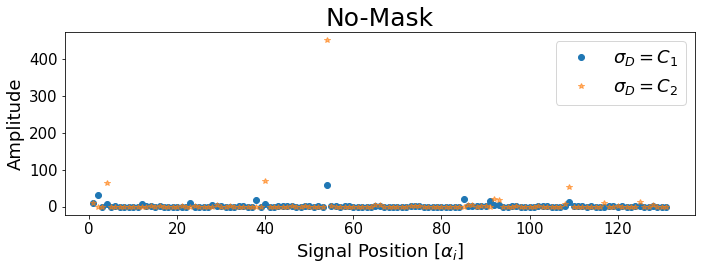

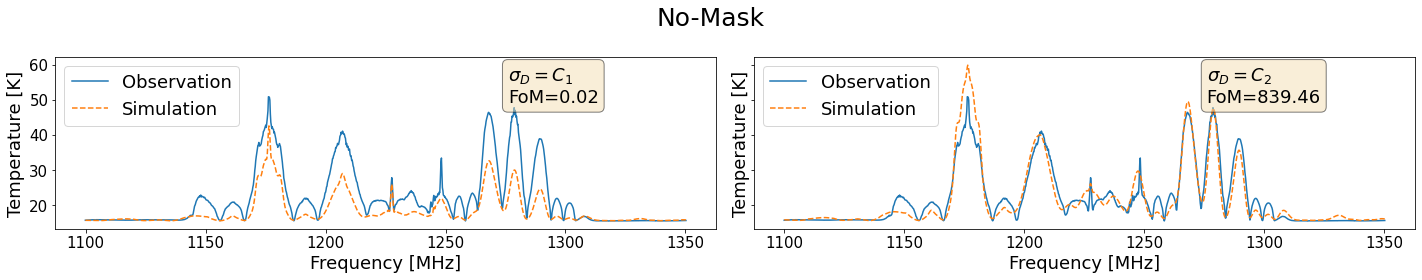

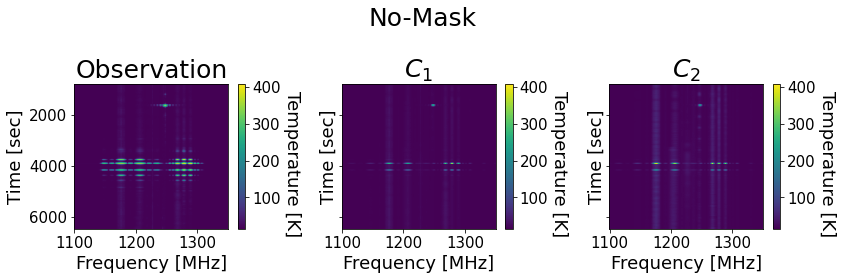

In [9]:
# plotting all things
plot_alphas_nomask(alphas)
plot_1d_nomask(sims, CFs)
plot_2d_nomask(sims)


#### 3.2 Angular masking

Now we create functions to display the plots, we use these ones for the rest of the masks.

In [10]:
# getting values
pars = [1,5]
alphas,sims,CFs,obs_BGsubs = get_results("deg",pars)

Getting values for deg = 1 and CF = C1.
Getting values for deg = 1 and CF = C2.
Getting values for deg = 5 and CF = C1.
Getting values for deg = 5 and CF = C2.


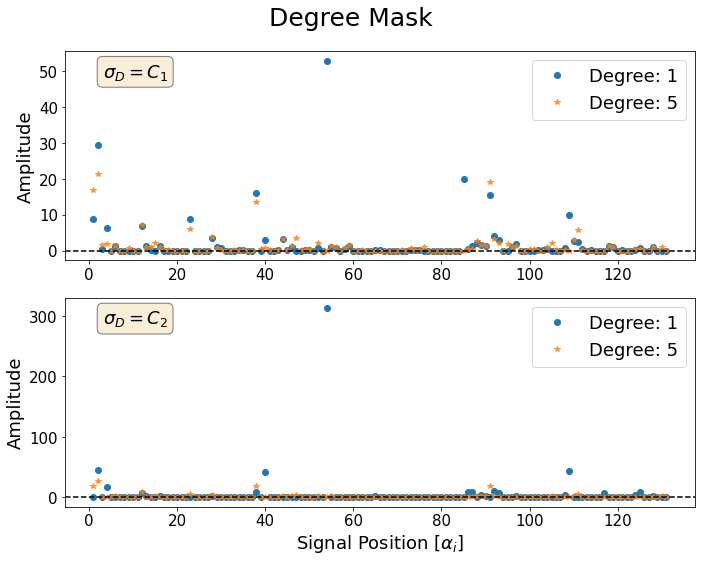

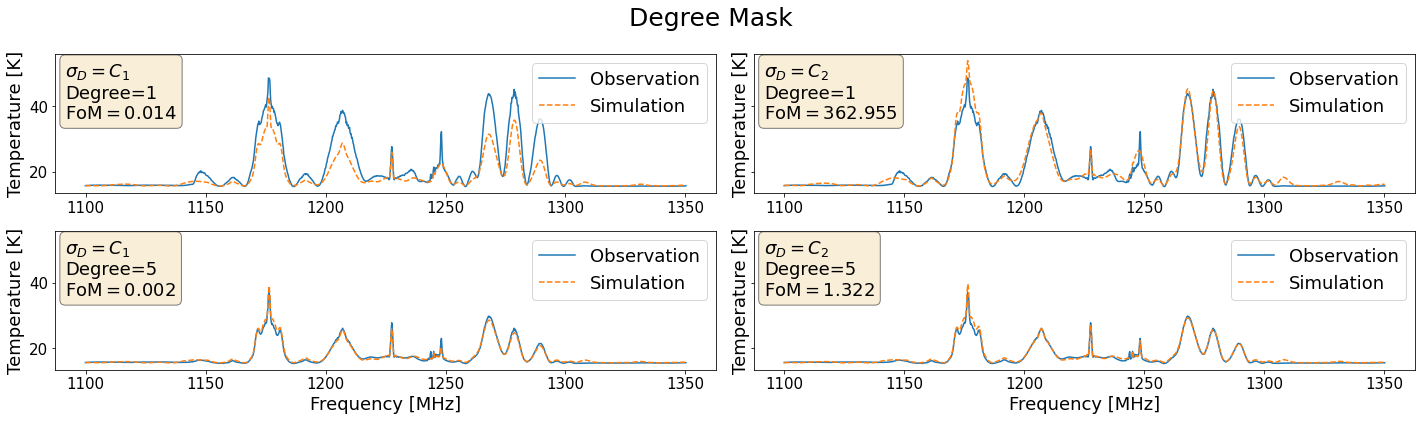

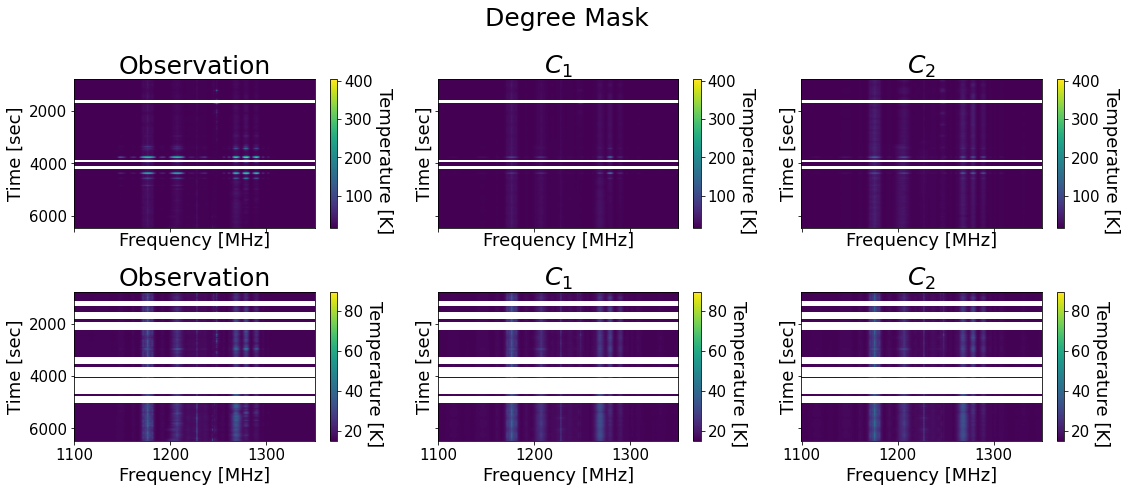

In [11]:
# showing plots
title = "Degree"
plot_alphas(alphas, pars, title)
plot_1d(obs_BGsubs, sims, CFs, pars, title)
plot_2d(obs_BGsubs, sims, pars, title)


#### 3.3 Thermal masking

In [12]:
# getting values
pars = [25,50,100]
alphas,sims,CFs,obs_BGsubs = get_results("temp",pars)

Getting values for temp = 25 and CF = C1.
Getting values for temp = 25 and CF = C2.
Getting values for temp = 50 and CF = C1.
Getting values for temp = 50 and CF = C2.
Getting values for temp = 100 and CF = C1.
Getting values for temp = 100 and CF = C2.


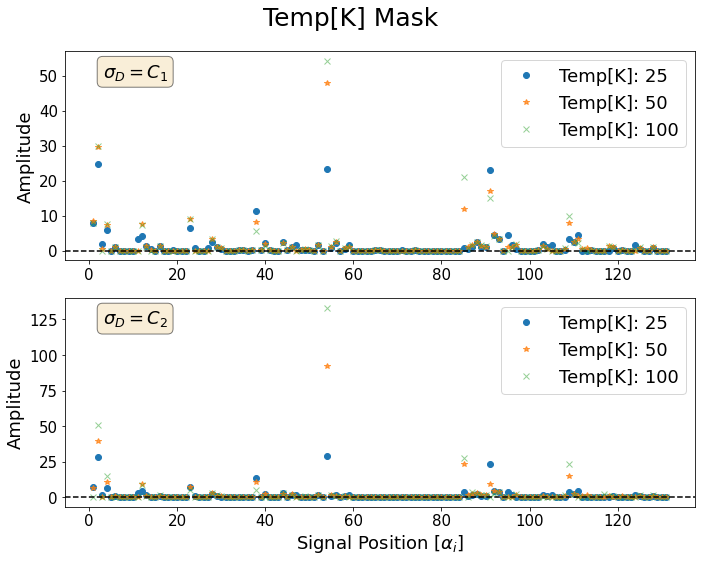

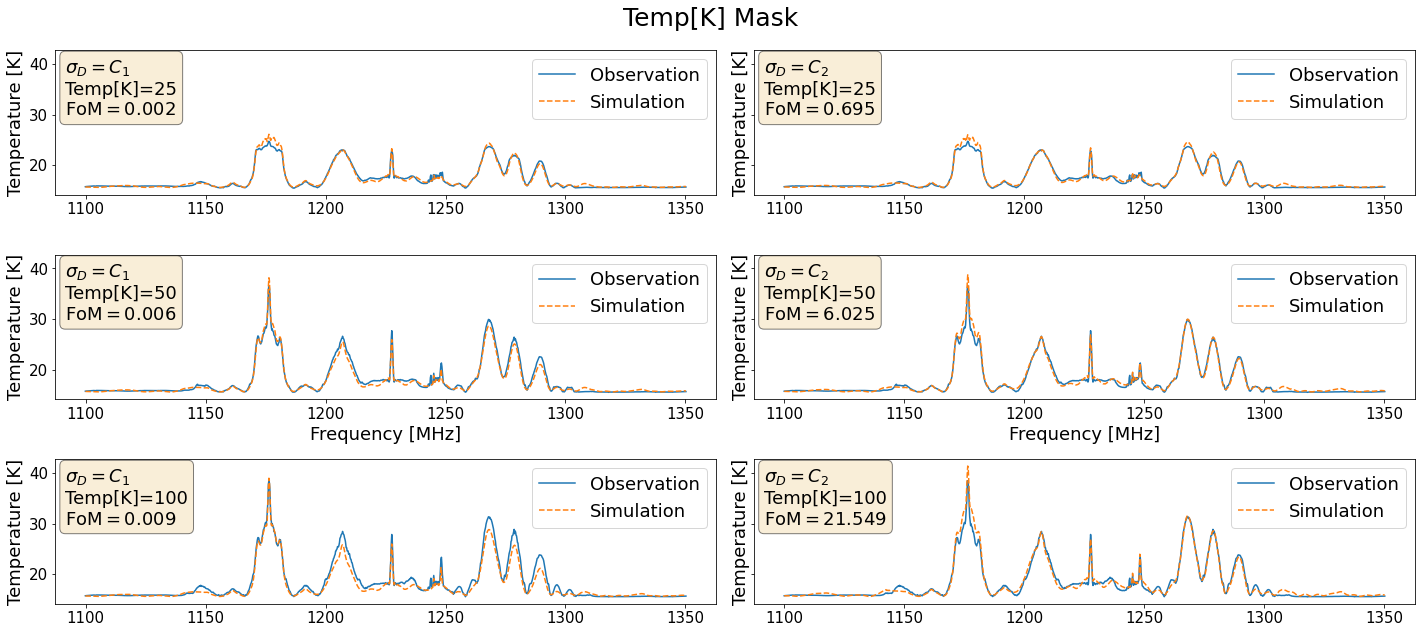

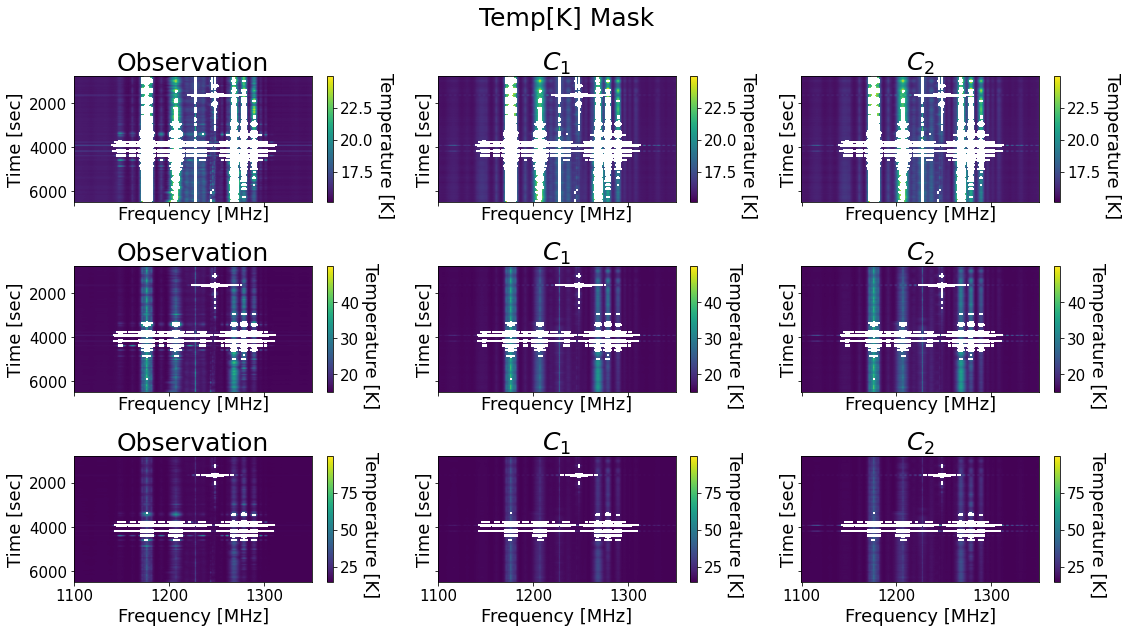

In [13]:
# showing plots
pars_mask = [25,50,100]
title = "Temp[K]"
plot_alphas(alphas, pars_mask, title)
plot_1d(obs_BGsubs, sims, CFs, pars_mask, title)
plot_2d(obs_BGsubs, sims, pars_mask, title)

#### 3.4 Pixel-timeline Masking

In [14]:
# getting values
pars = [2,5,7]
alphas,sims,CFs,obs_BGsubs = get_results("pix",pars)

Getting values for pix = 2 and CF = C1.
Getting values for pix = 2 and CF = C2.
Getting values for pix = 5 and CF = C1.
Getting values for pix = 5 and CF = C2.
Getting values for pix = 7 and CF = C1.
Getting values for pix = 7 and CF = C2.


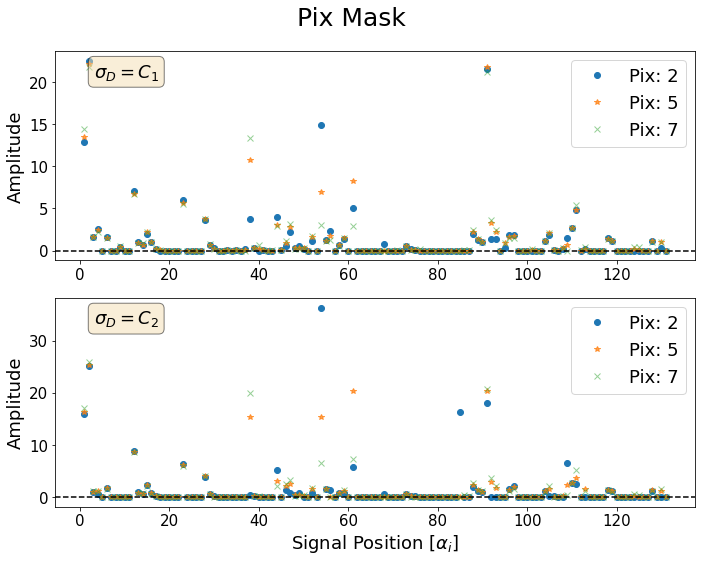

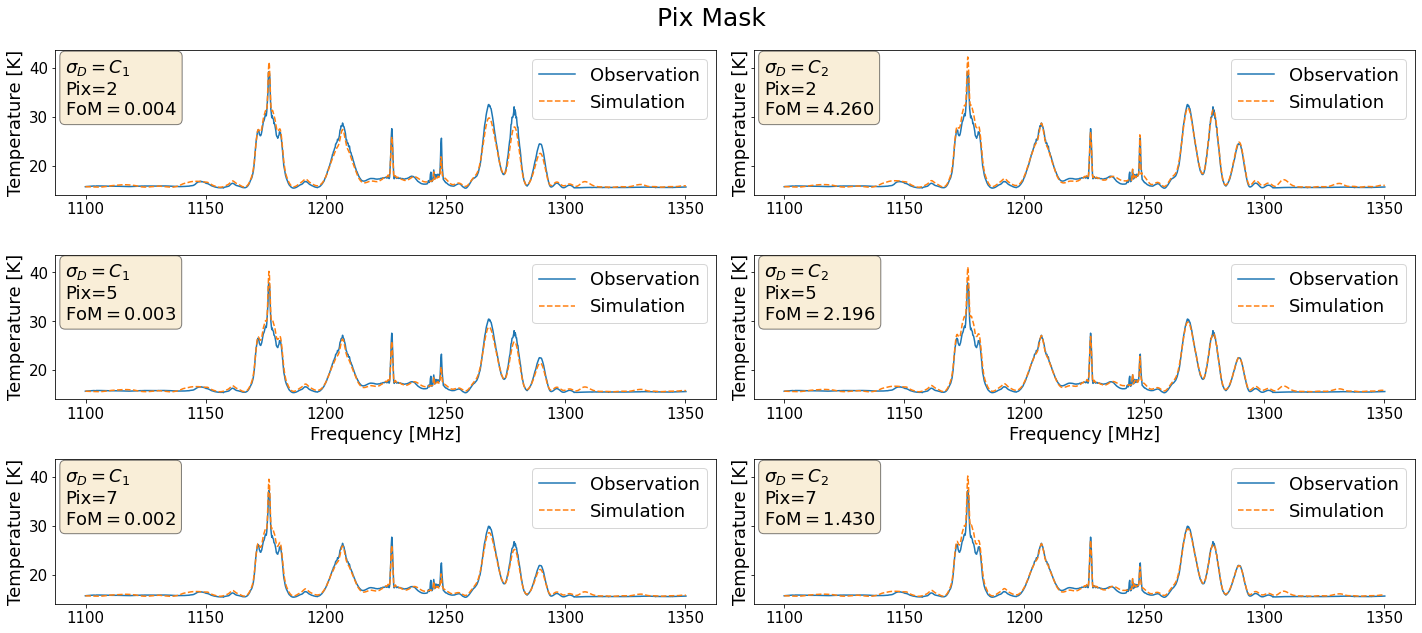

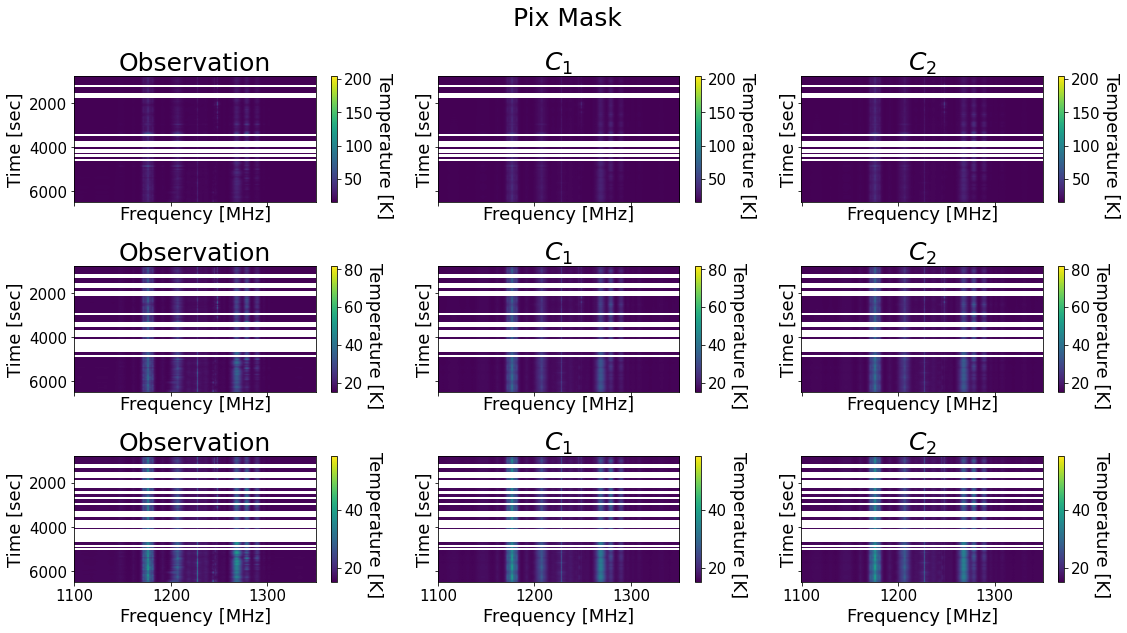

In [15]:
# showing plots
pars_mask = [2,5,7]
title = "Pix"
plot_alphas(alphas, pars_mask, title)
plot_1d(obs_BGsubs, sims, CFs, pars_mask, title)
plot_2d(obs_BGsubs, sims, pars_mask, title)

#### 3.5 Time slicing

In [16]:
## ----- PLOTTING FUNCTIONS FOR TSLICE ----- ##

def get_results_tslice(pars):
    ''' Retrieve alphas from the file for the timeslice scenario. '''

    # storing values
    alphas = {p: [] for p in pars}
    sims = {p: [] for p in pars}
    CFs = {p: [] for p in pars}
    obs_BGsubs = {}
    times = {}

    for p in pars:

        # creating simulation
        # we can use the same object throughout everything, only the mask changes
        sat = sim.SatelliteSimulation(
            survey_info=[pm.nd_s0, pm.frequency],
            path_catalog=path_catalog,
            path_beam=path_beam,
            freq_range=pm.freq_range,
            freq_slice=pm.freq_slice,
            time_slice=p,
            verbose=False,
            label_sats=label_sats,
        )
        
        # getting observations
        sat.use_observations(path_observations=pm.path_observations, verbose=False)

        # only time array is different, frequency and N are the same
        times[p] = sat.time[sat.itime[0]:sat.itime[1]]
        Npoints = sat.obs_BGsub.size
        obs_BGsubs[p] = sat.obs_BGsub.T
    
        for CF in ["C1","C2"]:
            # getting values
            print(f"Getting values for tslice = {p} and CF = {CF}.")
            alphasi = pickle.load( open(pm.my_name(folder=folder,CF=CF,time_slice=p),
                                        "rb") )["best-fit"]
            sat.simulate(alphasi)
            alphas[p].append(alphasi)
            sims[p].append(sat.sim.T)
            
            # calculating CF
            matrix = sat.obs_BGsub-sat.sim
            if CF=="C1":  CFs[p].append(np.sum((matrix/sat.obs)**2) / Npoints)
            else:  CFs[p].append(np.sum(matrix**2) / Npoints)
    return alphas, sims, CFs, obs_BGsubs, times

# ----------------------------------------------- #

def plot_alphas_tslice(alphas, pars):
    ''' Creates the plot of alpha values for C1 and C2. '''

    # creating figures
    points = ['o', '*', 'x', '.', 'o']
    fig, axs = plt.subplots(figsize=(10, 8), nrows=2, ncols=1, sharey=False)

    # plotting values
    xs = np.arange(1, N + 1)
    for i,p in enumerate(pars):
        axs[0].plot(xs, alphas[p][0], points[i], alpha=(1-i/4), label=f"Tslice: {p}")
        axs[1].plot(xs, alphas[p][1], points[i], alpha=(1-i/4), label=f"Tslice: {p}")

    # showing figure
    fig.suptitle(r'Tslice Mask')
    for i,CF in enumerate(["C_1","C_2"]):
        ax = axs[i]
        ax.set_ylabel('Amplitude')
        textstr = r"$\sigma_D={}$".format(CF)
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
        ax.axhline(0, color='black', linestyle='--')
        ax.legend()
    axs[1].set_xlabel(r'Signal Position $[\alpha_{i}]$')
    fig.tight_layout()
    fig.show()

# ----------------------------------------------- #

def plot_1d_tslice(obs_BGsubs, sims, CFs, pars):
    ''' Creates the plots for 1d comparison between data and simulation. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(20, 3*len(pars)), nrows=len(pars), ncols=2, sharey=True)
    fig.suptitle(r'Tslice Mask')

    for iCF,CF in enumerate(["C_1","C_2"]):
        for ilabel,label in enumerate(pars):
            
            # plotting values
            ax = axs[ilabel,iCF]
            ax.plot(frequency, np.ma.mean(obs_BGsubs[label], axis=0), label='Observation')
            ax.plot(frequency, np.ma.mean(sims[label][iCF], axis=0), '--', label='Simulation')

            # defining figure
            textstr = "$\\sigma_D={}$\nTslice={}\nFoM$={:.3f}$".format(CF,label,CFs[label][iCF])
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18, 
                    verticalalignment='top', bbox=props)
            if ilabel==1:  ax.set_xlabel('Frequency [MHz]')
            ax.set_ylabel('Temperature [K]')
            ax.legend(loc='upper right')

    # showing figure
    fig.tight_layout()
    fig.show()

# ----------------------------------- #

def plot_2d_tslice(obs_BGsubs, sims, times, pars):
    ''' Creates the plots for 2d comparison between data and simulation. ''' 

    # creating figures
    super_titles = ['Observation', r'$C_1$', r'$C_2$']
    fig,axs = plt.subplots(figsize=(16,3+2*len(pars)), nrows=len(pars), ncols=3,
                           sharey=False, sharex=False)
    fig.suptitle("Tslice Mask")

    for ilabel,label in enumerate(pars):
        for idata,data in enumerate([obs_BGsubs[label], sims[label][0], sims[label][1]]):
            # plotting values
            ax = axs[ilabel,idata]
            default = obs_BGsubs[label]
            cax = ax.imshow(data, aspect='auto', 
                            extent=[frequency[0],frequency[-1],times[label][-1],times[label][0]], 
                            vmax=np.max(default), vmin=np.ma.min(default))
    
            # defining figure
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            ax.set_title(super_titles[idata])
            ax.set_ylabel('Time [sec]')
            ax.set_xlabel('Frequency [MHz]')

    # showing figure
    fig.tight_layout()
    fig.show()
    

In [17]:
# getting values
pars = [(775,1000), (2200,2400), (5500,6200)]  # <-- need to be tuples
alphas,sims,CFs,obs_BGsubs,times = get_results_tslice(pars)

Getting values for tslice = (775, 1000) and CF = C1.
Getting values for tslice = (775, 1000) and CF = C2.
Getting values for tslice = (2200, 2400) and CF = C1.
Getting values for tslice = (2200, 2400) and CF = C2.
Getting values for tslice = (5500, 6200) and CF = C1.
Getting values for tslice = (5500, 6200) and CF = C2.


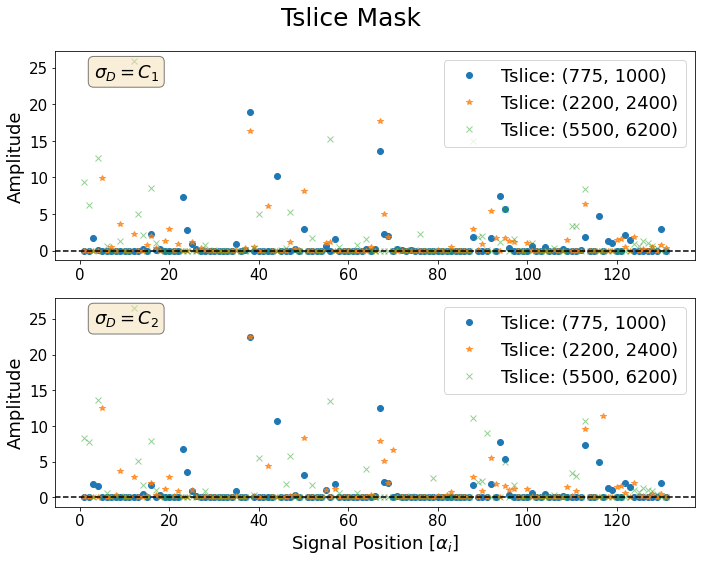

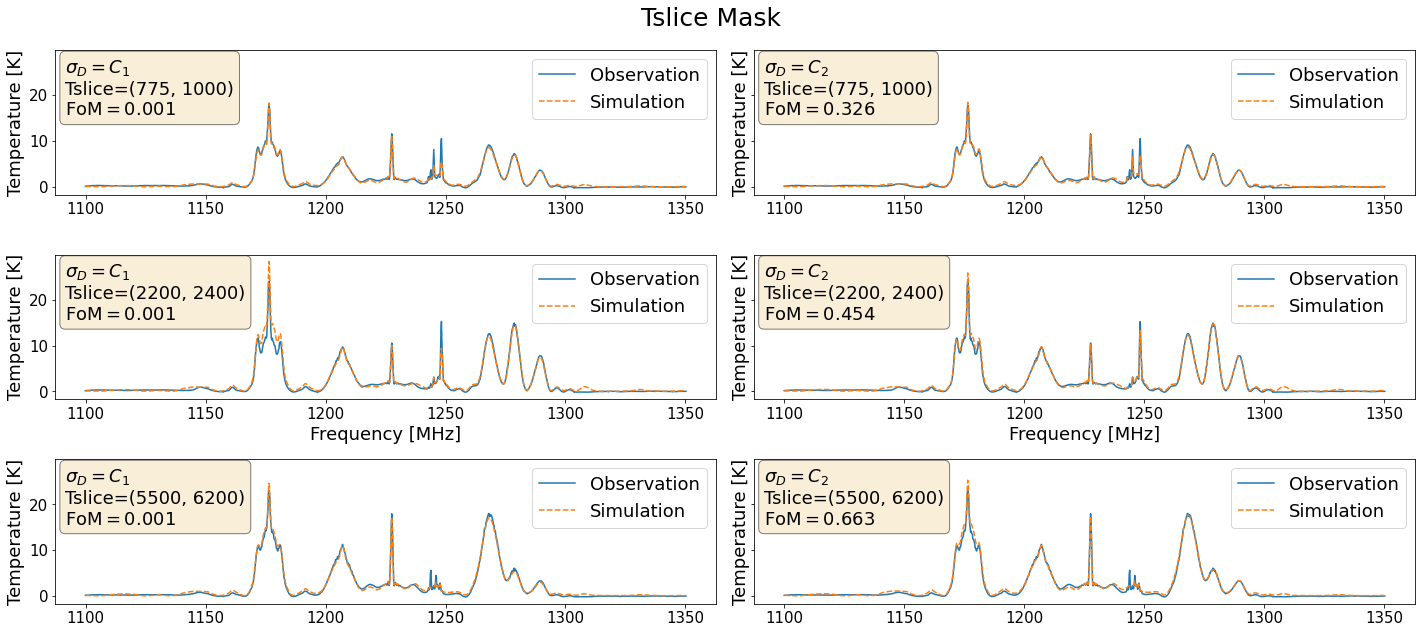

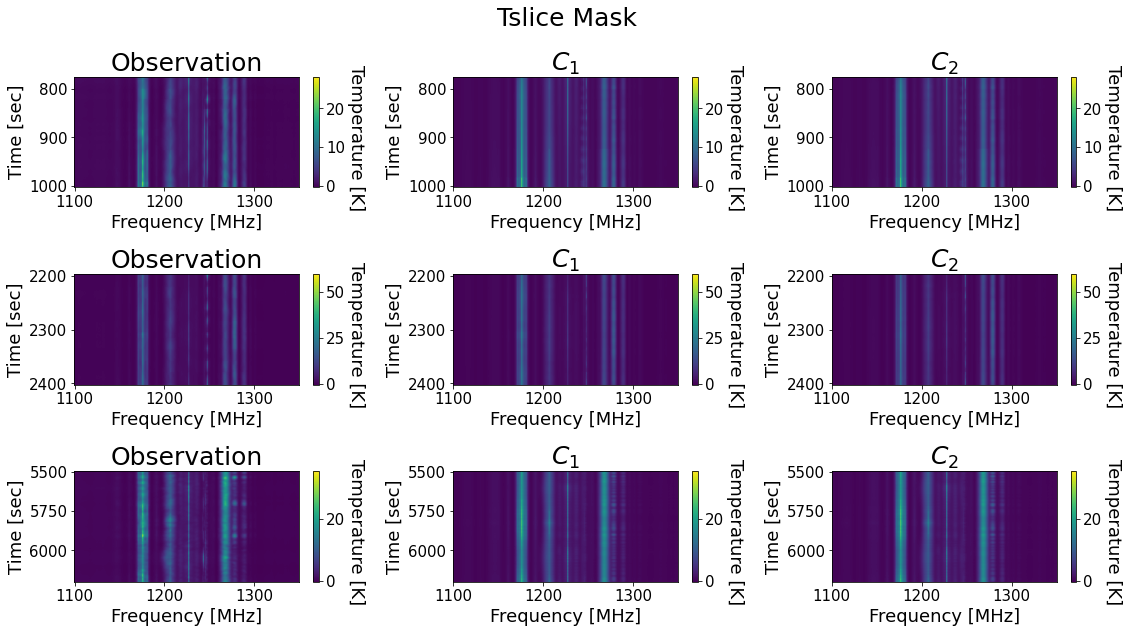

In [18]:
# showing plots
plot_alphas_tslice(alphas, pars)
plot_1d_tslice(obs_BGsubs, sims, CFs, pars)
plot_2d_tslice(obs_BGsubs, sims, times, pars)